# ECON526: Assignment 5

## Student Name/Number: Ryan Quek 81771206

### Instructions

-   Ensure you modify the field above with your **name and student
    number above immediately**
-   Modify directly and save as the `.ipynb`, and submit directly. Do
    not export to PDF or HTML, and leave the filename as is. Canvas will
    automatically append your name to the filename.
-   Submit directly to canvas as a `.ipynb` file.

## Setup

Feel free to use the following packages (and we have added a few
convenience imports)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import pandas as pd

This problem set will analyze data from the [Illinois Workplace Wellness
Study.](https://github.com/reifjulian/illinois-wellness-data). This
study is described and analyzed by Jones, Molitor, and Reif (2019) and
Reif et al. (2020). Consider reading all the questions (especially 7)
before working on any of them.

# Question 1

Read section II, “Experimental Design” of Jones, Molitor, and Reif
(2019). Briefly (5 or fewer sentences) describe the treatment and
outcomes in this study.

All part time and full time staff eligible for benefits were first invited to do an online survey on their baseline health and wellness. Thereafter, people who completed the survey were considered to be part of the study and were randomly assigned to the treatment and control group. The Treatment Group were then put into iThrive, consisting of a online survey and Health Risk Assessment, and invited to take part in wellness activities, with varying cash rewards given at each stage. They found that survey participants were more likely to be younger, white, female, have lower income, and more likely to be administrative staff. They also found that they were more likely to take part in one of the Illinois running events and have lower baseline medical spending.  

# Question 2

We will begin by focusing on total medical spending as the outcome. This
variable is available in the claims data set in
https://github.com/reifjulian/illinois-wellness-data . The documentation
for this data is
https://github.com/reifjulian/illinois-wellness-data/blob/master/data/codebooks/claims.codebook.txt
. What are the names of the treatment and medical spending outcome
variables in this data?

Treatment Variable:
treat

Eg. of Medical Spending Outcome Variables:
spend_0816_0119
spend_0816_0717

# Question 3

The following code downloads the claims data and loads it.

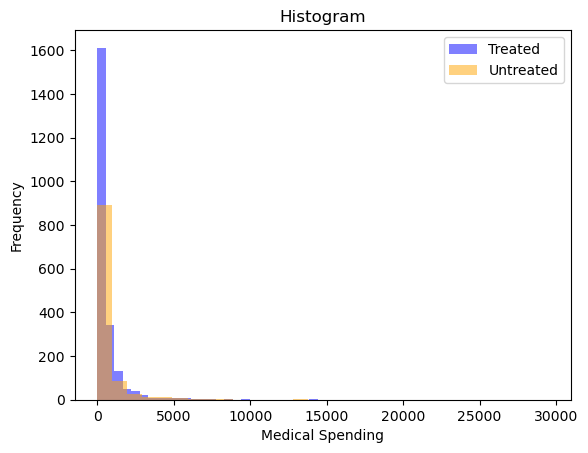

In [27]:
claims=pd.read_stata("https://github.com/reifjulian/illinois-wellness-data/raw/refs/heads/master/data/stata/claims.dta")

treated = claims[claims['treat']==1]
untreated = claims[claims['treat']==0]

plt.hist(treated['spend_0816_0119'],bins=30,alpha=0.5,label="Treated", color="Blue")
plt.hist(untreated['spend_0816_0119'],bins=30,alpha=0.5,label="Untreated", color="Orange")
plt.xlabel('Medical Spending')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.legend() 
plt.show()


Create a histogram of the outcome variable, which has the distributions
of the outcome for the treatment and control groups overlaid on top of
each other in different colors. Make the histogram transparent so that
you can clearly see both distributions. Add a legend to the plot to
indicate which distribution is which.

# Question 4

Estimate the average treatment effect (ATE) using the difference in
sample means as your estimator. Print each sample average and your point
estimate of the ATE as formatted strings. Interpret your result in the
markdown cell below.

In [28]:
treated.dropna()
untreated.dropna()
treatedeffect=np.mean(treated['spend_0816_0119'])
untreatedeffect=np.mean(untreated['spend_0816_0119'])
ate=treatedeffect-untreatedeffect
print(ate)

print(f"Sample average of Treated Population: ${treatedeffect}")
print(f"Sample average of Untreated Population: ${untreatedeffect}")
print(f"Average Treatment effect: ${ate}")



-126.51343
Sample average of Treated Population: $605.1500244140625
Sample average of Untreated Population: $731.6634521484375
Average Treatment effect: $-126.513427734375


This means that on average, a person in the treated population would have a typical monthly reduction of $126.51 in bills.

# Question 5

Use the standard error formula to calculate the asymptotic standard
errors of each of the sample means, and use these to construct a 95%
confidence interval for the ATE. Print all output in formatted strings.
In the markdown cell below, interpret your confidence interval.

In [29]:
# your code here

SDtreated=np.std(treated['spend_0816_0119'])
SDuntreated=np.std(untreated['spend_0816_0119'])

SEtreated=SDtreated/np.sqrt(len(treated))
SEuntreated=SDuntreated/np.sqrt(len(untreated))
SEate=np.sqrt((SEtreated**2)+(SEuntreated**2))

print(f"Standard Error of Treated Population: ${SEtreated}")
print(f"Standard Error of Untreated Population: ${SEuntreated}")
print(f"Standard Error of ATE: ${SEate}")



def normalci(estimate, se, level=0.95):
    return (estimate + se*scipy.stats.norm.ppf((1-level)/2),
            estimate + se*scipy.stats.norm.ppf(1-(1-level)/2))

ateCI=normalci(ate,SEate)
print(f"Confidence Interval for ATE: {ateCI}")

Standard Error of Treated Population: $20.609438733410244
Standard Error of Untreated Population: $49.07779329047925
Standard Error of ATE: $53.229491441955375
Confidence Interval for ATE: (-230.84131387599058, -22.185541592759435)


It means that 95% of people in the treated group had a reduction of between $22.19 and $230.84 in average monthly medical treatment bills.

# Question 6

Construct a 95% confidence interval using bootstrapping. Use 999
bootstrap samples. Are the results different? Is this what you expected?
Explain in the markdown cell below.

In [43]:
np.random.seed(100) # do not change this line
# your code here

import seaborn as sns

treatedsamp=treated['spend_0816_0119'].dropna()
untreatedsamp=untreated['spend_0816_0119'].dropna()

def bootstrap(treateff,untreateff,realate, B=999):
    bestimates=[]
    for _ in range(B):
        treatedchoice=np.random.choice(treateff,size=len(treateff),replace=True)
        untreatedchoice=np.random.choice(untreateff,size=len(untreateff),replace=True)
        bestimates.append((np.mean(treatedchoice)-np.mean(untreatedchoice))-realate)
    return bestimates



def bootstrapci(treateff,untreateff,ate, B=999, level=0.95):
    estimates = bootstrap(treateff, untreateff,ate, B)
    lo = np.percentile(estimates, 100*(1-level)/2) + ate
    hi = np.percentile(estimates, 100*(1-(1-level)/2)) + ate
    return lo, hi

bootstrapci(treatedsamp,untreatedsamp,ate,999)

(-259.97038879394523, -3.8334533691408836)

The range is a little bit wider. This is likely because the Bootstrap uses a sample of observations and possibly the difference in medical bills could be rather large. 

# Question 7

Choose one (or more if you want, but no need) other outcome to analyze.
It can be in claims data, but could also be in one of the [other
datasets from the
study](https://github.com/reifjulian/illinois-wellness-data/tree/master/data/stata).

## 7.1

Report the ATE and a 95% confidence interval for this outcome. Briefly
describe the results.

In [ ]:
treatedeffect2=np.mean(treated['spendRx_0816_0119'])
untreatedeffect2=np.mean(untreated['spendRx_0816_0119'])
ate2=treatedeffect2-untreatedeffect2

print(f"Sample average of Treated Population: ${treatedeffect2}")
print(f"Sample average of Untreated Population: ${untreatedeffect2}")
print(f"Average Treatment effect: ${ate2}")


SDtreated2=np.std(treated['spendRx_0816_0119'])
SDuntreated2=np.std(untreated['spendRx_0816_0119'])

SEtreated2=SDtreated2/np.sqrt(len(treated))
SEuntreated2=SDuntreated2/np.sqrt(len(untreated))
SEate2=np.sqrt((SEtreated2**2)+(SEuntreated2**2))

print(f"Standard Error of Treated Population: ${SEtreated2}")
print(f"Standard Error of Untreated Population: ${SEuntreated2}")
print(f"Standard Error of ATE: ${SEate2}")



def normalci(estimate, se, level=0.95):
    return (estimate + se*scipy.stats.norm.ppf((1-level)/2),
            estimate + se*scipy.stats.norm.ppf(1-(1-level)/2))

ateCI2=normalci(ate2,SEate2)
print(f"Confidence Interval for ATE: {ateCI2}")

-25.036072
Sample average of Treated Population: $137.37124633789062
Sample average of Untreated Population: $162.40731811523438
Average Treatment effect: $-25.03607177734375
Standard Error of Treated Population: $10.731920426725258
Standard Error of Untreated Population: $18.865753214112946
Standard Error of ATE: $21.704625322298835
Confidence Interval for ATE: (-67.57635570698554, 17.50421215229803)


I've opted to look at Pharmaceutical Spending to see whether the outcomes found earlier would be similar if we excluded Serious Incidents/Illnesses (ie looking at only pharmaceutical spending). The confidence interval does cross zero (into positive territory), and the average treatment effect is significantly lower in magnitude than the original.

This means that in terms of Pharmaceutical spend, the costs of prescriptions did not drop as much in the treatment population, meaning that perhaps the treatment population saw effects in avoiding major health incidents, but not necessarily minor ones (like common cold etc that would necessitate just a prescription but no hospital stay) 

## 7.2

Repeating identical or similar code is generally regarded as poor style.
Repetitive code can be hard to maintain and modify.

Did your answer to 7.1 involve repeating a lot of code similar to what
you had for questions 1-6? If yes, how could your code be reorganized to
reduce repetition? If no, how did you avoid repetition?

Yes. I could possibly organise it by setting up functions such that I do not need to repeat the calls again. However, I'm a little bit slower with setting up functions, so I would try it again another time, but for submissions, to play safe I just copied the code instead.

# References

Jones, Damon, David Molitor, and Julian Reif. 2019.
“<span class="nocase">What do Workplace Wellness Programs do? Evidence
from the Illinois Workplace Wellness Study\*</span>.” *The Quarterly
Journal of Economics* 134 (4): 1747–91.
<https://doi.org/10.1093/qje/qjz023>.

Reif, Julian, David Chan, Damon Jones, Laura Payne, and David Molitor.
2020. “<span class="nocase">Effects of a Workplace Wellness Program on
Employee Health, Health Beliefs, and Medical Use: A Randomized Clinical
Trial</span>.” *JAMA Internal Medicine* 180 (7): 952–60.
<https://doi.org/10.1001/jamainternmed.2020.1321>.